# 경제국면 자산배분 — 기존 4개 자산 고수익·MDD 15% 절충안

사용자 선택에 따라 **신규 헤지 자산은 추가하지 않았다.** 투자되는 위험자산은 원 노트북과 동일한 `KODEX200`, 국내 `BOND`, `GLD`, `USO`뿐이다.

최종 중앙값 후보는 원 고수익 전략 40%와 기존 방어 전략 60%를 섞고, 총자산 노출을 1.20배로 유지한다. 20% 차입에는 연 4% 금융비용을 매월 차감한다.

> 전체기간 결과: **CAGR 14.30%, Sharpe 1.024, MDD -14.90%**  
> 2018년 이후 잠금구간: **CAGR 17.07%, Sharpe 1.164, MDD -14.90%**

이 수치는 역사적 시뮬레이션이며 미래 MDD 15%를 보장하지 않는다. 특히 비용 2배와 블록 부트스트랩 결과를 함께 확인해야 한다.

## 1. 선택 원칙과 검증 구조

- **자산 제한:** 네 자산만 매수한다. 옵션, VIX 상품, 인버스, 관리선물은 없다.
- **핵심 비중:** `0.40 × 원 고수익 국면비중 + 0.60 × 기존 방어비중`.
- **총노출:** 위 혼합비중에 1.20을 곱한다. 음의 현금 20%는 헤지 자산이 아니라 명시적 차입이다.
- **비용:** 자산 비중 변화 절댓값에 15bp, 해외자산 순변화에 5bp, 차입 연 4%를 차감한다.
- **시점:** 원 노트북의 발표시차 및 `t월 말 신호 → t+1월 첫 거래일` 규칙을 유지한다.
- **보정구간:** 2017-12까지. **잠금구간:** 2018-01 이후.
- **후보 선택 감사:** ML·VIX 동적 방어는 보정 성과가 높아도 잠금구간에서 무너져 제외했다. 두 매개변수 고정혼합을 채택해 모델 위험을 줄였다.

보정 경계의 1.25배 후보는 전체 MDD가 -15.58%였기 때문에 제외하고, 인접 중앙값인 1.20배를 고정했다.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ROOT = Path.cwd()
RESULTS = ROOT / "results"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

print("작업 폴더:", ROOT)
print("투자 자산:", ["KODEX200", "BOND", "GLD", "USO"])
print("신규 헤지 자산: 없음")

작업 폴더: D:\Programming\python_example\RegimeDecisionTest
투자 자산: ['KODEX200', 'BOND', 'GLD', 'USO']
신규 헤지 자산: 없음


## 2. 원 노트북의 데이터·국면·방어모델 구현

아래 숨김 셀은 거시 입력변수, 발표시차, Sparse Jump Model, 경기·물가 확률, 공분산 추정, 제약 최적화, drawdown guard, 거래비용을 포함한다.

In [2]:
from __future__ import annotations

import json
import math
import sqlite3
import unicodedata
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

warnings.filterwarnings("ignore", category=FutureWarning)

ASSETS = ["KODEX200", "BOND", "GLD", "USO"]
ROOT = Path.cwd()
RAW_DIR = ROOT / "raw_data"
CACHE_DIR = ROOT / "cache"
RESULTS_DIR = ROOT / "results"
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


def get_path(directory: Path, filename: str) -> Path:
    target = unicodedata.normalize("NFC", filename)
    for path in directory.iterdir():
        if unicodedata.normalize("NFC", path.name) == target:
            return path
    raise FileNotFoundError(filename)


def rolling_zscore(series: pd.Series, window: int, clip: float = 3.0) -> pd.Series:
    mean = series.rolling(window, min_periods=window).mean()
    std = series.rolling(window, min_periods=window).std(ddof=1).replace(0, np.nan)
    return ((series - mean) / std).clip(-clip, clip)


def load_macro_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    gdp = pd.read_excel(get_path(RAW_DIR, "GDP 성장률.xlsx"), index_col=0, skiprows=6)
    gdp.columns = ["QoQ", "YoY"]
    gdp.index = pd.PeriodIndex(gdp.index, freq="Q").asfreq("M", how="end").to_timestamp("M") + pd.offsets.MonthEnd(1)
    gdp = gdp.resample("ME").ffill()

    trade = pd.read_excel(get_path(RAW_DIR, "수출입 총괄_20260816.xlsx"), index_col=0, skiprows=4)
    trade = trade[["수출 금액", "수입금액"]].iloc[1:].copy()
    for col in trade.columns:
        trade[col] = trade[col].astype(str).str.replace(",", "", regex=False).astype(float)
    trade.index = pd.to_datetime(trade.index, format="%Y.%m") + pd.offsets.MonthEnd(1)
    trade["Export_YoY"] = trade["수출 금액"].pct_change(12) * 100

    bsi = pd.read_csv(get_path(RAW_DIR, "기업경기조사(전망).csv"), encoding="cp949")
    bsi = bsi[(bsi["업종코드별"] == "제 조 업") & (bsi["BSI코드별"] == "업황전망BSI 1)")]
    bsi = bsi.iloc[:, 2:4].copy()
    bsi["시점"] = bsi["시점"].str.replace("월", "", regex=False).str.replace(" ", "", regex=False)
    bsi["시점"] = pd.to_datetime(bsi["시점"], format="%Y.%m") + pd.offsets.MonthEnd(1)
    bsi = bsi.set_index("시점")
    bsi.columns = ["BSI"]

    cpi = pd.read_excel(get_path(RAW_DIR, "소비자물가 상승률.xlsx"), index_col=0, skiprows=6)
    cpi.columns = ["CPI_QoQ", "CPI_YoY"]
    cpi.index = pd.to_datetime(cpi.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    ppi = pd.read_excel(get_path(RAW_DIR, "생산자물가 상승률.xlsx"), index_col=0, skiprows=6)
    ppi.columns = ["PPI_QoQ", "PPI_YoY"]
    ppi.index = pd.to_datetime(ppi.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    prices = pd.read_excel(get_path(RAW_DIR, "수출입물가 상승률.xlsx"), index_col=0, skiprows=6)
    prices.columns = ["ExportPrice_YoY", "ImportPrice_YoY"]
    prices.index = pd.to_datetime(prices.index, format="%Y-%m") + pd.offsets.MonthEnd(2)

    core = pd.concat(
        {
            "GDP": rolling_zscore(gdp["YoY"], 72),
            "Export": rolling_zscore(trade["Export_YoY"], 36),
            "BSI": rolling_zscore(bsi["BSI"], 24),
            "CPI": rolling_zscore(cpi["CPI_YoY"], 36),
            "PPI": rolling_zscore(ppi["PPI_YoY"], 36),
            "ImportPrice": rolling_zscore(prices["ImportPrice_YoY"], 36),
        },
        axis=1,
    ).sort_index()

    # Levels describe the phase; 3-month changes help identify turning points.
    growth = core[["GDP", "Export", "BSI"]].copy()
    growth.columns = ["GDP_level", "Export_level", "BSI_level"]
    growth = pd.concat([growth, growth.diff(3).add_suffix("_d3")], axis=1)
    inflation = core[["CPI", "PPI", "ImportPrice"]].copy()
    inflation.columns = ["CPI_level", "PPI_level", "ImportPrice_level"]
    inflation = pd.concat([inflation, inflation.diff(3).add_suffix("_d3")], axis=1)
    features = pd.concat({"growth": growth, "inflation": inflation}, axis=1).dropna()
    return features, core


def download_market_cache(refresh: bool = False) -> pd.DataFrame:
    cache = CACHE_DIR / "market_daily.csv"
    if cache.exists() and not refresh:
        out = pd.read_csv(cache, parse_dates=["date"])
        return out

    import yfinance as yf

    rows: list[pd.DataFrame] = []
    for ticker, symbol in [("069500.KS", "KODEX200"), ("GLD", "GLD"), ("USO", "USO"), ("KRW=X", "USDKRW")]:
        data = yf.download(ticker, start="2000-01-01", auto_adjust=(symbol != "USDKRW"), progress=False, threads=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data = data.reset_index().rename(columns={"Date": "date", "Open": "open", "Close": "close"})
        data["date"] = pd.to_datetime(data["date"], utc=True).dt.tz_localize(None).dt.normalize()
        data["symbol"] = symbol
        rows.append(data[["date", "symbol", "open", "close"]])
    out = pd.concat(rows, ignore_index=True).dropna(subset=["date", "close"])
    out.to_csv(cache, index=False)
    return out


def load_monthly_asset_returns(refresh: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    market = download_market_cache(refresh)

    with sqlite3.connect(get_path(RAW_DIR, "compass.db")) as con:
        proxy = pd.read_sql(
            "select date, open, close from etf_prices where symbol = ? order by date",
            con,
            params=("1028",),
        )
    proxy["date"] = pd.to_datetime(proxy["date"])
    proxy[["open", "close"]] = proxy[["open", "close"]].apply(pd.to_numeric, errors="coerce")

    actual = market[market["symbol"] == "KODEX200"].copy().dropna(subset=["open"])
    # Yahoo contains a sparse early fragment followed by a long gap.  Use the
    # continuous KOSPI200 proxy through March 2009, then splice the ETF series.
    actual = actual[actual["date"] > pd.Timestamp("2009-03-31")]
    first_actual = actual["date"].min()
    actual_anchor = actual.loc[actual["date"] == first_actual, "open"].iloc[0]
    proxy_anchor = proxy.loc[proxy["date"] == first_actual, "open"]
    if proxy_anchor.empty:
        nearest = proxy.iloc[(proxy["date"] - first_actual).abs().argsort()[:1]]
        proxy_anchor_value = float(nearest["open"].iloc[0])
    else:
        proxy_anchor_value = float(proxy_anchor.iloc[0])
    proxy["open"] = proxy["open"] * float(actual_anchor) / proxy_anchor_value
    proxy["close"] = proxy["close"] * float(actual_anchor) / proxy_anchor_value
    proxy = proxy[proxy["date"] < first_actual]
    proxy["symbol"] = "KODEX200"
    kodex = pd.concat([proxy[["date", "symbol", "open", "close"]], actual], ignore_index=True)

    bond = pd.read_csv(get_path(RAW_DIR, "krx_bond_index.csv"), encoding="cp949")
    bond["date"] = pd.to_datetime(bond.iloc[:, 0])
    bond["open"] = bond.iloc[:, 1].astype(str).str.replace(",", "", regex=False).astype(float)
    bond["close"] = bond["open"]
    bond["symbol"] = "BOND"

    fx = market[market["symbol"] == "USDKRW"].set_index("date")["close"].sort_index()
    fx = fx.reindex(pd.date_range(fx.index.min(), fx.index.max(), freq="D")).ffill()

    first_open: dict[str, pd.Series] = {}
    trade_dates: dict[str, pd.Series] = {}
    for symbol, data in {
        "KODEX200": kodex,
        "BOND": bond,
        "GLD": market[market["symbol"] == "GLD"],
        "USO": market[market["symbol"] == "USO"],
    }.items():
        temp = data.dropna(subset=["open"]).sort_values("date").copy()
        temp["month"] = temp["date"].dt.to_period("M")
        first = temp.groupby("month", sort=True).first()
        value = first["open"].astype(float)
        if symbol in {"GLD", "USO"}:
            value = value * fx.reindex(pd.DatetimeIndex(first["date"]), method="ffill").to_numpy()
        first_open[symbol] = value
        trade_dates[symbol] = first["date"]

    levels = pd.concat(first_open, axis=1).sort_index()
    returns = levels.shift(-1).div(levels).sub(1.0).dropna(how="any")
    returns = returns[ASSETS]
    return returns, levels[ASSETS]


def _softmax(values: np.ndarray) -> np.ndarray:
    z = values - np.max(values)
    exp = np.exp(z)
    return exp / exp.sum()


class SparseJump2:
    """Small, transparent two-state sparse jump model.

    It alternates between sparse feature weighting/centroid estimation and a
    dynamic-programming state sequence with an explicit switching penalty.
    """

    def __init__(self, jump_penalty: float = 3.0, keep_features: int = 4, max_iter: int = 30):
        self.jump_penalty = float(jump_penalty)
        self.keep_features = int(keep_features)
        self.max_iter = int(max_iter)

    @staticmethod
    def _dp(dist: np.ndarray, jump: float) -> tuple[np.ndarray, np.ndarray]:
        n = len(dist)
        costs = np.zeros((n, 2))
        back = np.zeros((n, 2), dtype=int)
        costs[0] = dist[0]
        for t in range(1, n):
            for k in range(2):
                candidates = costs[t - 1] + jump * (np.arange(2) != k)
                back[t, k] = int(np.argmin(candidates))
                costs[t, k] = dist[t, k] + candidates[back[t, k]]
        states = np.zeros(n, dtype=int)
        states[-1] = int(np.argmin(costs[-1]))
        for t in range(n - 2, -1, -1):
            states[t] = back[t + 1, states[t + 1]]
        return states, costs

    def fit_predict_high(self, frame: pd.DataFrame) -> tuple[float, dict]:
        x_raw = frame.to_numpy(dtype=float)
        med = np.nanmedian(x_raw, axis=0)
        scale = np.nanpercentile(x_raw, 75, axis=0) - np.nanpercentile(x_raw, 25, axis=0)
        scale = np.where(scale < 0.15, np.nanstd(x_raw, axis=0), scale)
        scale = np.where(scale < 1e-6, 1.0, scale)
        x = np.clip((x_raw - med) / scale, -5, 5)

        score = np.nanmean(x[:, : min(3, x.shape[1])], axis=1)
        states = (score > np.nanmedian(score)).astype(int)
        weights = np.ones(x.shape[1]) / x.shape[1]
        for _ in range(self.max_iter):
            old = states.copy()
            centers = np.vstack([
                x[states == k].mean(axis=0) if np.any(states == k) else np.nanmean(x, axis=0)
                for k in range(2)
            ])
            within = np.vstack([
                np.nanvar(x[states == k], axis=0) if np.sum(states == k) > 1 else np.ones(x.shape[1])
                for k in range(2)
            ]).mean(axis=0)
            separation = (centers[1] - centers[0]) ** 2 / (within + 0.20)
            keep = np.argsort(separation)[-min(self.keep_features, len(separation)) :]
            weights = np.zeros_like(separation)
            weights[keep] = np.maximum(separation[keep], 1e-4)
            weights /= weights.sum()
            dist = np.stack([((x - centers[k]) ** 2 * weights).sum(axis=1) for k in range(2)], axis=1)
            states, costs = self._dp(dist, self.jump_penalty)
            if np.array_equal(states, old):
                break

        centers = np.vstack([x[states == k].mean(axis=0) for k in range(2)])
        high_state = int(np.argmax(centers[:, : min(3, x.shape[1])].mean(axis=1)))
        prev_state = int(states[-2]) if len(states) > 1 else int(states[-1])
        local_dist = np.array([((x[-1] - centers[k]) ** 2 * weights).sum() for k in range(2)])
        local_cost = local_dist + self.jump_penalty * 0.55 * (np.arange(2) != prev_state)
        probs = _softmax(-local_cost / 0.85)
        p_high = float(np.clip(probs[high_state], 0.03, 0.97))
        detail = {
            "p_high": p_high,
            "state": int(states[-1]),
            "high_state": high_state,
            "switches": int(np.sum(states[1:] != states[:-1])),
            "feature_weights": dict(zip(frame.columns, weights)),
        }
        return p_high, detail


def compute_regime_signals(features: pd.DataFrame, returns: pd.DataFrame, jump_penalty: float = 3.0, min_history: int = 24) -> pd.DataFrame:
    rows = []
    model = SparseJump2(jump_penalty=jump_penalty, keep_features=4)
    pg_prev = 0.5
    pi_prev = 0.5
    for target_month in returns.index:
        signal_month = target_month - 1
        hist = features.loc[: signal_month.to_timestamp("M")]
        if len(hist) < min_history:
            continue
        pg_sjm, gd = model.fit_predict_high(hist["growth"])
        pi_sjm, id_ = model.fit_predict_high(hist["inflation"])
        growth_now = float(hist["growth"].iloc[-1][["GDP_level", "Export_level", "BSI_level"]].mean())
        growth_mom = float(hist["growth"].iloc[-1][["GDP_level_d3", "Export_level_d3", "BSI_level_d3"]].mean())
        inflation_now = float(hist["inflation"].iloc[-1][["CPI_level", "PPI_level", "ImportPrice_level"]].mean())
        inflation_mom = float(hist["inflation"].iloc[-1][["CPI_level_d3", "PPI_level_d3", "ImportPrice_level_d3"]].mean())
        pg_composite = float(expit((growth_now + 0.20 * growth_mom) / 0.55))
        pi_composite = float(expit((inflation_now + 0.20 * inflation_mom) / 0.55))
        # The transparent composite is the primary forecast because the sample
        # is small; SJM contributes sparse selection and switch persistence.
        pg_raw = 0.10 * pg_sjm + 0.90 * pg_composite
        pi_raw = 0.10 * pi_sjm + 0.90 * pi_composite
        pg = 0.85 * pg_raw + 0.15 * pg_prev
        pi = 0.85 * pi_raw + 0.15 * pi_prev
        pg_prev, pi_prev = pg, pi
        probs = {
            "Goldilocks": pg * (1 - pi),
            "Overheating": pg * pi,
            "Slowdown": (1 - pg) * (1 - pi),
            "Stagflation": (1 - pg) * pi,
        }
        regime = max(probs, key=probs.get)
        rows.append(
            {
                "target_month": target_month,
                "signal_month": signal_month,
                "p_growth_high": pg,
                "p_inflation_high": pi,
                "p_growth_sjm": pg_sjm,
                "p_inflation_sjm": pi_sjm,
                "growth_composite": growth_now,
                "inflation_composite": inflation_now,
                "regime": regime,
                **{f"p_{k}": v for k, v in probs.items()},
                "growth_switches": gd["switches"],
                "inflation_switches": id_["switches"],
                "growth_features": json.dumps(gd["feature_weights"], ensure_ascii=False),
                "inflation_features": json.dumps(id_["feature_weights"], ensure_ascii=False),
            }
        )
    return pd.DataFrame(rows).set_index("target_month")


REGIME_ANCHORS = pd.DataFrame(
    {
        "Goldilocks": [0.58, 0.22, 0.15, 0.05],
        "Overheating": [0.30, 0.12, 0.23, 0.35],
        "Slowdown": [0.12, 0.66, 0.20, 0.02],
        "Stagflation": [0.08, 0.24, 0.50, 0.18],
    },
    index=ASSETS,
).T
DEFENSIVE = np.array([0.05, 0.72, 0.23, 0.00])
STRATEGIC = np.array([0.20, 0.45, 0.30, 0.05])


def soft_anchor(signal: pd.Series) -> np.ndarray:
    p = np.array([signal[f"p_{r}"] for r in REGIME_ANCHORS.index])
    return p @ REGIME_ANCHORS.to_numpy()


def ewma_cov(history: pd.DataFrame, half_life: float = 12.0, leverage: float = 1.0) -> np.ndarray:
    x = history[ASSETS].to_numpy(dtype=float)
    if len(x) < 12:
        return np.cov(x, rowvar=False) + np.eye(len(ASSETS)) * 1e-6
    alpha = 1 - math.exp(math.log(0.5) / half_life)
    cov = np.cov(x[: min(24, len(x))], rowvar=False)
    mean = np.nanmean(x, axis=0)
    for row in x:
        shock = row - mean
        multiplier = 1.0 + leverage * min(max(-row[0], 0.0) / 0.08, 1.5)
        cov = (1 - alpha) * cov + alpha * multiplier * np.outer(shock, shock)
    return cov + np.eye(len(ASSETS)) * 1e-7


def cdar(returns: np.ndarray, alpha: float = 0.90) -> float:
    wealth = np.cumprod(1 + returns)
    dd = wealth / np.maximum.accumulate(np.r_[1.0, wealth])[-len(wealth):] - 1.0
    k = max(1, int(math.ceil((1 - alpha) * len(dd))))
    return float(np.mean(np.sort(dd)[:k]))


@dataclass
class StrategyConfig:
    name: str = "Proposed"
    target_vol: float = 0.08
    half_life: float = 12.0
    invvol_tilt: float = 0.35
    return_reward: float = 1.15
    vol_penalty: float = 0.18
    cdar_penalty: float = 0.25
    turnover_penalty: float = 0.05
    tracking_penalty: float = 0.32
    max_cdar: float = 0.16
    drawdown_guard: float = 0.75
    regime_strength: float = 0.75
    use_regime: bool = True
    use_risk_control: bool = True


def controlled_weights(
    signal: pd.Series,
    history: pd.DataFrame,
    pretrade: np.ndarray,
    current_dd: float,
    cfg: StrategyConfig,
) -> np.ndarray:
    anchor = soft_anchor(signal) if cfg.use_regime else STRATEGIC.copy()
    anchor = cfg.regime_strength * anchor + (1 - cfg.regime_strength) * STRATEGIC
    if not cfg.use_risk_control or len(history) < 24:
        return anchor

    cov = ewma_cov(history.tail(84), cfg.half_life, leverage=1.0)
    vols = np.sqrt(np.diag(cov)).clip(0.005, None)
    tilted = anchor * (np.median(vols) / vols) ** cfg.invvol_tilt
    tilted = tilted / tilted.sum()
    prior = 0.55 * anchor + 0.45 * tilted

    hist = history.tail(84)[ASSETS]
    long_mu = history[ASSETS].expanding(min_periods=24).mean().iloc[-1].to_numpy()
    recent_mu = hist.ewm(halflife=24, adjust=False).mean().iloc[-1].to_numpy()
    mu = 0.80 * long_mu + 0.20 * recent_mu
    mu = np.clip(mu, -0.006, 0.015)
    target = cfg.target_vol * (0.86 + 0.20 * float(signal["p_growth_high"]))

    def objective(w: np.ndarray) -> float:
        ann_return = 12 * float(w @ mu)
        ann_vol = math.sqrt(max(float(w @ cov @ w), 0.0) * 12)
        path_cdar = abs(cdar(hist.to_numpy() @ w, 0.90))
        turnover = 0.5 * np.sum(np.sqrt((w - pretrade) ** 2 + 1e-6))
        tracking = float(np.sum((w - prior) ** 2))
        return (
            -cfg.return_reward * ann_return
            + cfg.vol_penalty * ann_vol
            + cfg.cdar_penalty * path_cdar
            + cfg.turnover_penalty * turnover
            + cfg.tracking_penalty * tracking
        )

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: target - math.sqrt(max(float(w @ cov @ w), 0.0) * 12)},
        {"type": "ineq", "fun": lambda w: cfg.max_cdar + cdar(hist.to_numpy() @ w, 0.90)},
    ]
    bounds = [(0.02, 0.68), (0.05, 0.88), (0.02, 0.62), (0.0, 0.38)]
    result = minimize(objective, prior, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter": 80, "ftol": 1e-8})
    w = result.x if result.success and np.isfinite(result.x).all() else prior
    w = np.clip(w, 0, None)
    w /= w.sum()

    # MPC-style state-dependent risk aversion: react to realized drawdown, but
    # retain a floor in risky assets so recovery participation is not lost.
    if current_dd < -0.05:
        severity = min(max((-current_dd - 0.05) / 0.12, 0.0), 1.0)
        blend = cfg.drawdown_guard * (0.25 + 0.50 * severity)
        w = (1 - blend) * w + blend * DEFENSIVE
    return w / w.sum()


def hard_regime_weights(signal: pd.Series) -> np.ndarray:
    mapping = {
        "Goldilocks": np.array([1.0, 0.0, 0.0, 0.0]),
        "Overheating": np.array([0.0, 0.0, 0.0, 1.0]),
        "Slowdown": np.array([0.6, 0.4, 0.0, 0.0]),
        "Stagflation": np.array([0.0, 0.0, 1.0, 0.0]),
    }
    return mapping[signal["regime"]]


def run_backtest(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    cfg: StrategyConfig,
    mode: str = "proposed",
    start: str | None = None,
    end: str | None = None,
    cost_multiplier: float = 1.0,
) -> pd.DataFrame:
    months = signals.index.intersection(returns.index)
    if start:
        months = months[months >= pd.Period(start, "M")]
    if end:
        months = months[months <= pd.Period(end, "M")]
    rows = []
    pretrade = np.zeros(4)
    first_trade = True
    nav = 1.0
    peak = 1.0
    for month in months:
        signal = signals.loc[month]
        history = returns.loc[returns.index < month]
        current_dd = nav / peak - 1.0
        if mode == "proposed":
            w = controlled_weights(signal, history, pretrade, current_dd, cfg)
        elif mode == "soft":
            w = soft_anchor(signal)
        elif mode == "hard":
            w = hard_regime_weights(signal)
        elif mode == "equal":
            w = np.full(4, 0.25)
        elif mode == "static_defensive":
            w = np.array([0.20, 0.45, 0.30, 0.05])
        elif mode == "kodex":
            w = np.array([1.0, 0.0, 0.0, 0.0])
        else:
            raise ValueError(mode)

        delta = w - pretrade
        turnover = np.abs(delta).sum() if first_trade else 0.5 * np.abs(delta).sum()
        trade_cost = np.abs(delta).sum() * 0.0015 * cost_multiplier
        fx_cost = abs((w[2] + w[3]) - (pretrade[2] + pretrade[3])) * 0.0005 * cost_multiplier
        gross_return = float(w @ returns.loc[month, ASSETS].to_numpy())
        net_return = gross_return - trade_cost - fx_cost
        nav *= 1 + net_return
        peak = max(peak, nav)
        end_w = w * (1 + returns.loc[month, ASSETS].to_numpy()) / (1 + gross_return)
        rows.append(
            {
                "month": month,
                "signal_month": signal["signal_month"],
                "regime": signal["regime"],
                "p_growth_high": signal["p_growth_high"],
                "p_inflation_high": signal["p_inflation_high"],
                "gross_return": gross_return,
                "return": net_return,
                "turnover": turnover,
                "trade_cost": trade_cost,
                "fx_cost": fx_cost,
                "nav": nav,
                "drawdown": nav / peak - 1,
                **{f"w_{a}": w[i] for i, a in enumerate(ASSETS)},
            }
        )
        pretrade = end_w
        first_trade = False
    return pd.DataFrame(rows).set_index("month")


def performance_summary(returns: pd.Series) -> pd.Series:
    r = pd.Series(returns).dropna()
    wealth = (1 + r).cumprod()
    years = len(r) / 12
    cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std(ddof=1) * math.sqrt(12)
    sharpe = r.mean() / r.std(ddof=1) * math.sqrt(12) if r.std(ddof=1) > 0 else np.nan
    dd = wealth / wealth.cummax() - 1
    mdd = dd.min()
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    downside = np.sqrt(np.mean(np.minimum(r, 0) ** 2)) * math.sqrt(12)
    sortino = r.mean() * 12 / downside if downside > 0 else np.nan
    return pd.Series(
        {
            "Months": len(r),
            "CAGR": cagr,
            "Volatility": vol,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "MDD": mdd,
            "Calmar": calmar,
            "FinalMultiple": wealth.iloc[-1],
            "PositiveMonths": (r > 0).mean(),
        }
    )


def evaluate_regimes(signals: pd.DataFrame, core: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    composite = pd.DataFrame(
        {
            "growth_realized": core[["GDP", "Export", "BSI"]].mean(axis=1),
            "inflation_realized": core[["CPI", "PPI", "ImportPrice"]].mean(axis=1),
        }
    )
    # Ex-post target: average of the next three published monthly readings.
    future = pd.concat([composite.shift(-k) for k in (1, 2, 3)], axis=1)
    future.columns = pd.MultiIndex.from_product([[1, 2, 3], composite.columns])
    target = pd.DataFrame(index=composite.index)
    target["growth_high_realized"] = future.xs("growth_realized", axis=1, level=1).mean(axis=1) >= 0
    target["inflation_high_realized"] = future.xs("inflation_realized", axis=1, level=1).mean(axis=1) >= 0
    pred = signals.copy()
    pred.index = pred["signal_month"].apply(lambda x: x.to_timestamp("M"))
    joined = pred.join(target, how="inner").dropna(subset=["growth_high_realized", "inflation_high_realized"])
    joined["growth_pred"] = joined["p_growth_high"] >= 0.5
    joined["inflation_pred"] = joined["p_inflation_high"] >= 0.5
    joined["quadrant_hit"] = (joined["growth_pred"] == joined["growth_high_realized"]) & (joined["inflation_pred"] == joined["inflation_high_realized"])
    metrics = {
        "growth_balanced_accuracy": balanced_accuracy_score(joined["growth_high_realized"], joined["growth_pred"]),
        "inflation_balanced_accuracy": balanced_accuracy_score(joined["inflation_high_realized"], joined["inflation_pred"]),
        "quadrant_accuracy": float(joined["quadrant_hit"].mean()),
        "n_months": len(joined),
        "growth_confusion": confusion_matrix(joined["growth_high_realized"], joined["growth_pred"]).tolist(),
        "inflation_confusion": confusion_matrix(joined["inflation_high_realized"], joined["inflation_pred"]).tolist(),
    }
    return joined, metrics



## 3. 고정혼합·금융비용 구현

원 전략은 경기국면별 기대수익 프리미엄을 강하게 취한다. 방어 전략은 국면 확률, 변동성, 상관관계와 낙폭을 이용해 분산한다. 두 전략을 일정 비율로 섞으면 예측모형이 특정 위기 직전에 맞아야 한다는 부담이 줄어든다.

1. `Goldilocks → KODEX200`, `Overheating → USO`, `Slowdown → KODEX200 60% + BOND 40%`, `Stagflation → GLD`가 원 고수익 비중이다.
2. 원 비중 40%와 기존 방어 비중 60%를 매월 혼합한다.
3. 기대수익을 회복하기 위해 동일 네 자산의 총노출만 1.20배로 확대한다.
4. 레버리지 때문에 수익과 손실, 비용이 모두 확대된다. 이 부분이 전략의 핵심 위험이다.

In [3]:
from __future__ import annotations

import itertools
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from regime_research import (
    ASSETS,
    StrategyConfig,
    compute_regime_signals,
    hard_regime_weights,
    load_macro_data,
    load_monthly_asset_returns,
    performance_summary,
    run_backtest,
)


ROOT = Path.cwd()
RESULTS = ROOT / "results"
CAL_END = pd.Period("2017-12", "M")


@dataclass(frozen=True)
class BlendConfig:
    hard_fraction: float
    leverage: float
    financing_rate: float = 0.04

    @property
    def name(self) -> str:
        return f"blend_h{self.hard_fraction:.3f}_lev{self.leverage:.2f}"


def run_blend(
    returns: pd.DataFrame,
    signals: pd.DataFrame,
    defensive_path: pd.DataFrame,
    cfg: BlendConfig,
    start: str | None = None,
    end: str | None = None,
    cost_multiplier: float = 1.0,
) -> pd.DataFrame:
    months = signals.index.intersection(returns.index).intersection(defensive_path.index)
    if start:
        months = months[months >= pd.Period(start, "M")]
    if end:
        months = months[months <= pd.Period(end, "M")]

    rows = []
    pretrade_assets = np.zeros(len(ASSETS))
    pretrade_debt = 0.0
    nav = 1.0
    peak = 1.0
    first_trade = True
    for month in months:
        hard = hard_regime_weights(signals.loc[month])
        defensive = defensive_path.loc[month, [f"w_{asset}" for asset in ASSETS]].to_numpy(dtype=float)
        unlevered = cfg.hard_fraction * hard + (1.0 - cfg.hard_fraction) * defensive
        asset_weights = cfg.leverage * unlevered
        debt_weight = 1.0 - cfg.leverage

        asset_delta = asset_weights - pretrade_assets
        turnover = np.abs(asset_delta).sum() if first_trade else 0.5 * np.abs(asset_delta).sum()
        trade_cost = np.abs(asset_delta).sum() * 0.0015 * cost_multiplier
        fx_cost = abs(
            (asset_weights[2] + asset_weights[3]) - (pretrade_assets[2] + pretrade_assets[3])
        ) * 0.0005 * cost_multiplier
        financing = debt_weight * ((1.0 + cfg.financing_rate) ** (1.0 / 12.0) - 1.0)
        asset_r = returns.loc[month, ASSETS].to_numpy(dtype=float)
        gross_return = float(asset_weights @ asset_r + financing)
        net_return = gross_return - trade_cost - fx_cost
        nav *= 1.0 + net_return
        peak = max(peak, nav)

        pretrade_assets = asset_weights * (1.0 + asset_r) / (1.0 + gross_return)
        pretrade_debt = debt_weight * (1.0 + cfg.financing_rate) ** (1.0 / 12.0) / (1.0 + gross_return)
        first_trade = False
        rows.append(
            {
                "month": month,
                "return": net_return,
                "gross_return": gross_return,
                "nav": nav,
                "drawdown": nav / peak - 1.0,
                "turnover": turnover,
                "trade_cost": trade_cost,
                "fx_cost": fx_cost,
                "financing_return": financing,
                "regime": signals.loc[month, "regime"],
                "hard_fraction": cfg.hard_fraction,
                "leverage": cfg.leverage,
                "debt_weight": debt_weight,
                **{f"w_{asset}": asset_weights[i] for i, asset in enumerate(ASSETS)},
                **{f"hard_w_{asset}": hard[i] for i, asset in enumerate(ASSETS)},
                **{f"defensive_w_{asset}": defensive[i] for i, asset in enumerate(ASSETS)},
            }
        )
    return pd.DataFrame(rows).set_index("month")



## 4. 데이터 로딩과 전략 재계산

In [4]:
macro, macro_core = load_macro_data()
asset_returns, asset_levels = load_monthly_asset_returns(refresh=False)
signals = compute_regime_signals(macro, asset_returns)

base_cfg = StrategyConfig()
hard = run_backtest(asset_returns, signals, base_cfg, mode="hard")
defensive = run_backtest(asset_returns, signals, base_cfg, mode="proposed")
final_cfg = BlendConfig(hard_fraction=0.40, leverage=1.20, financing_rate=0.04)
final = run_blend(asset_returns, signals, defensive, final_cfg)

audit = pd.DataFrame({
    "시작": [macro.index.min(), asset_returns.index.min(), signals.index.min(), final.index.min()],
    "종료": [macro.index.max(), asset_returns.index.max(), signals.index.max(), final.index.max()],
    "관측치": [len(macro), len(asset_returns), len(signals), len(final)],
}, index=["거시 입력변수", "자산 월수익률", "투자 신호", "최종 백테스트"])
display(audit)
display(pd.Series({
    "원 전략 비율": final_cfg.hard_fraction,
    "방어 전략 비율": 1-final_cfg.hard_fraction,
    "총자산 노출": final_cfg.leverage,
    "차입 비중": final_cfg.leverage-1,
    "연 금융비용 가정": final_cfg.financing_rate,
}, name="고정값").to_frame().style.format("{:.1%}"))

D:\Programming\python_example\Arcana\.venv-llama\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,시작,종료,관측치
거시 입력변수,2005-04-30 00:00:00,2026-07-31 00:00:00,256
자산 월수익률,2006-04,2026-07,244
투자 신호,2007-04,2026-07,232
최종 백테스트,2007-04,2026-07,232


,고정값
원 전략 비율,40.0%
방어 전략 비율,60.0%
총자산 노출,120.0%
차입 비중,20.0%
연 금융비용 가정,4.0%


## 5. 핵심 성과 — 보정·잠금·전체

In [5]:
rows = []
for period, start, end in [
    ("보정 2007-2017", None, "2017-12"),
    ("잠금 2018+", "2018-01", None),
    ("전체", None, None),
]:
    for strategy, bt in [("원 고수익", hard), ("기존 방어", defensive), ("최종 혼합", final)]:
        sample = bt.loc[start:end] if start else bt.loc[:end] if end else bt
        m = performance_summary(sample["return"])
        rows.append({"구간": period, "전략": strategy, **m.to_dict(), "월평균 회전율": sample["turnover"].mean()})

comparison = pd.DataFrame(rows)
display(comparison[["구간", "전략", "CAGR", "Volatility", "Sharpe", "Sortino", "MDD", "Calmar", "FinalMultiple", "월평균 회전율"]].style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.3f}", "Sortino": "{:.3f}",
    "MDD": "{:.2%}", "Calmar": "{:.3f}", "FinalMultiple": "{:.2f}x", "월평균 회전율": "{:.2%}",
}).highlight_max(subset=["CAGR", "Sharpe", "Calmar"], color="#d8f0dc"))

full_hard = performance_summary(hard["return"])
full_final = performance_summary(final["return"])
locked_final = performance_summary(final.loc["2018-01":, "return"])
display(pd.Series({
    "원 수익률 유지율": f'{full_final["CAGR"] / full_hard["CAGR"]:.1%}',
    "MDD 개선폭": f'{full_final["MDD"] - full_hard["MDD"]:.2%}',
    "전체 Sharpe": f'{full_final["Sharpe"]:.3f}',
    "잠금 Sharpe": f'{locked_final["Sharpe"]:.3f}',
}, name="핵심 판정").to_frame())

,구간,전략,CAGR,Volatility,Sharpe,Sortino,MDD,Calmar,FinalMultiple,월평균 회전율
0,보정 2007-2017,원 고수익,15.24%,21.52%,0.768,1.370,-25.25%,0.604,4.60x,10.80%
1,보정 2007-2017,기존 방어,7.38%,6.66%,1.105,2.018,-8.93%,0.826,2.15x,2.87%
2,보정 2007-2017,최종 혼합,12.14%,13.75%,0.904,1.669,-13.99%,0.867,3.43x,7.58%
3,잠금 2018+,원 고수익,22.61%,23.93%,0.979,1.632,-26.67%,0.848,5.75x,17.04%
4,잠금 2018+,기존 방어,9.05%,7.56%,1.187,2.527,-8.05%,1.125,2.10x,2.06%
5,잠금 2018+,최종 혼합,17.07%,14.52%,1.164,2.057,-14.90%,1.145,3.87x,10.13%
6,전체,원 고수익,18.46%,22.59%,0.867,1.492,-26.67%,0.692,26.44x,13.57%
7,전체,기존 방어,8.12%,7.06%,1.144,2.241,-8.93%,0.909,4.53x,2.51%
8,전체,최종 혼합,14.30%,14.08%,1.024,1.849,-14.90%,0.960,13.25x,8.71%


,핵심 판정
원 수익률 유지율,77.5%
MDD 개선폭,11.77%
전체 Sharpe,1.024
잠금 Sharpe,1.164


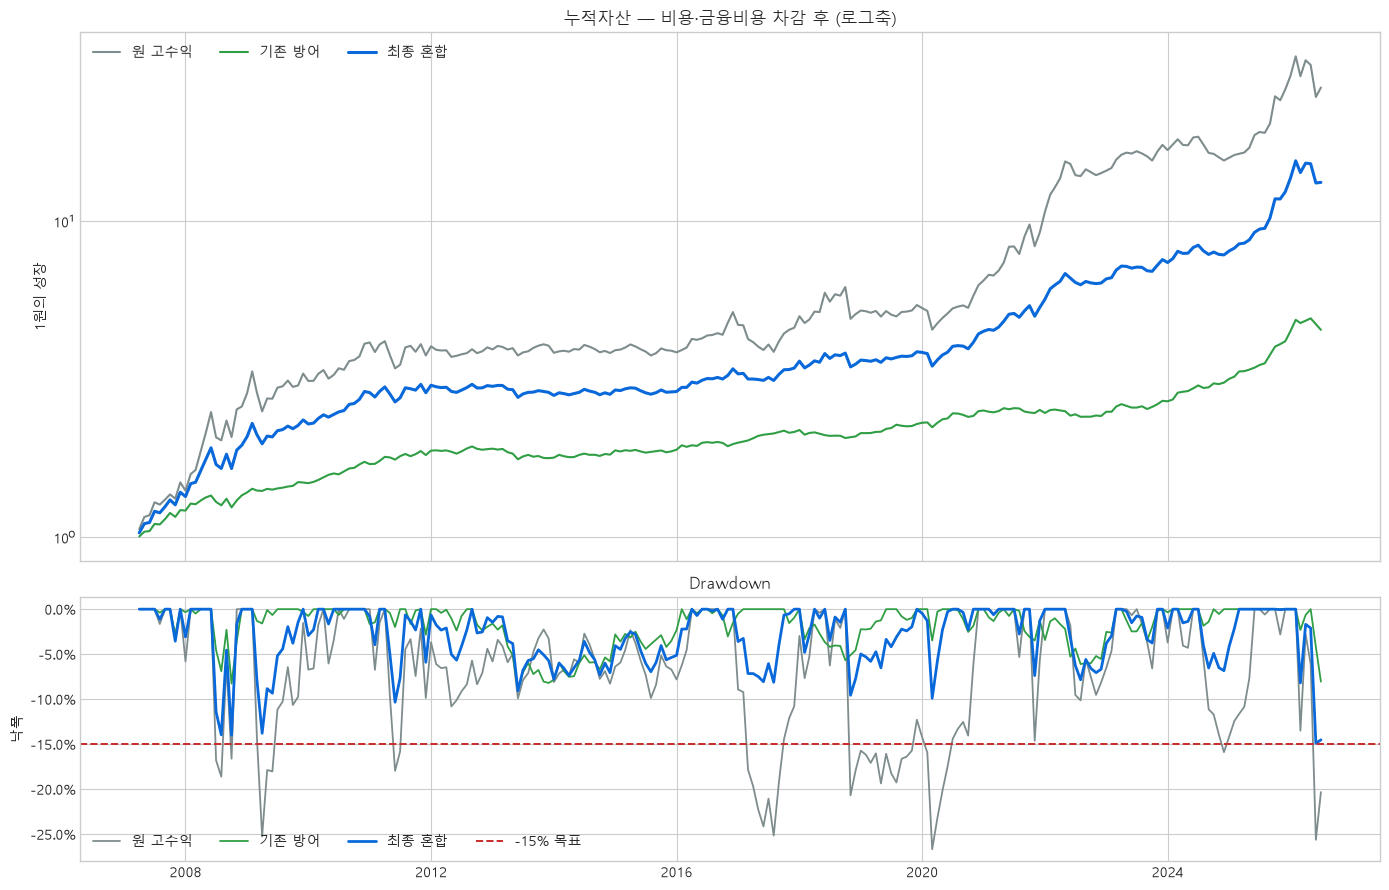

In [6]:
idx = final.index.to_timestamp()
wealth = {name: (1 + bt["return"]).cumprod() for name, bt in [("원 고수익", hard), ("기존 방어", defensive), ("최종 혼합", final)]}
drawdown = {name: values / values.cummax() - 1 for name, values in wealth.items()}
colors = {"원 고수익": "#7f8c8d", "기존 방어": "#2f9e44", "최종 혼합": "#0969da"}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for name in wealth:
    axes[0].plot(idx, wealth[name], label=name, color=colors[name], lw=2.2 if name == "최종 혼합" else 1.5)
axes[0].set_yscale("log")
axes[0].set_title("누적자산 — 비용·금융비용 차감 후 (로그축)")
axes[0].set_ylabel("1원의 성장")
axes[0].legend(ncol=3)
for name in drawdown:
    axes[1].plot(idx, drawdown[name], label=name, color=colors[name], lw=2 if name == "최종 혼합" else 1.3)
axes[1].axhline(-0.15, color="#c92a2a", ls="--", lw=1.4, label="-15% 목표")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("낙폭")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(ncol=4)
plt.tight_layout()
plt.show()

## 6. 실제 자산비중과 레버리지

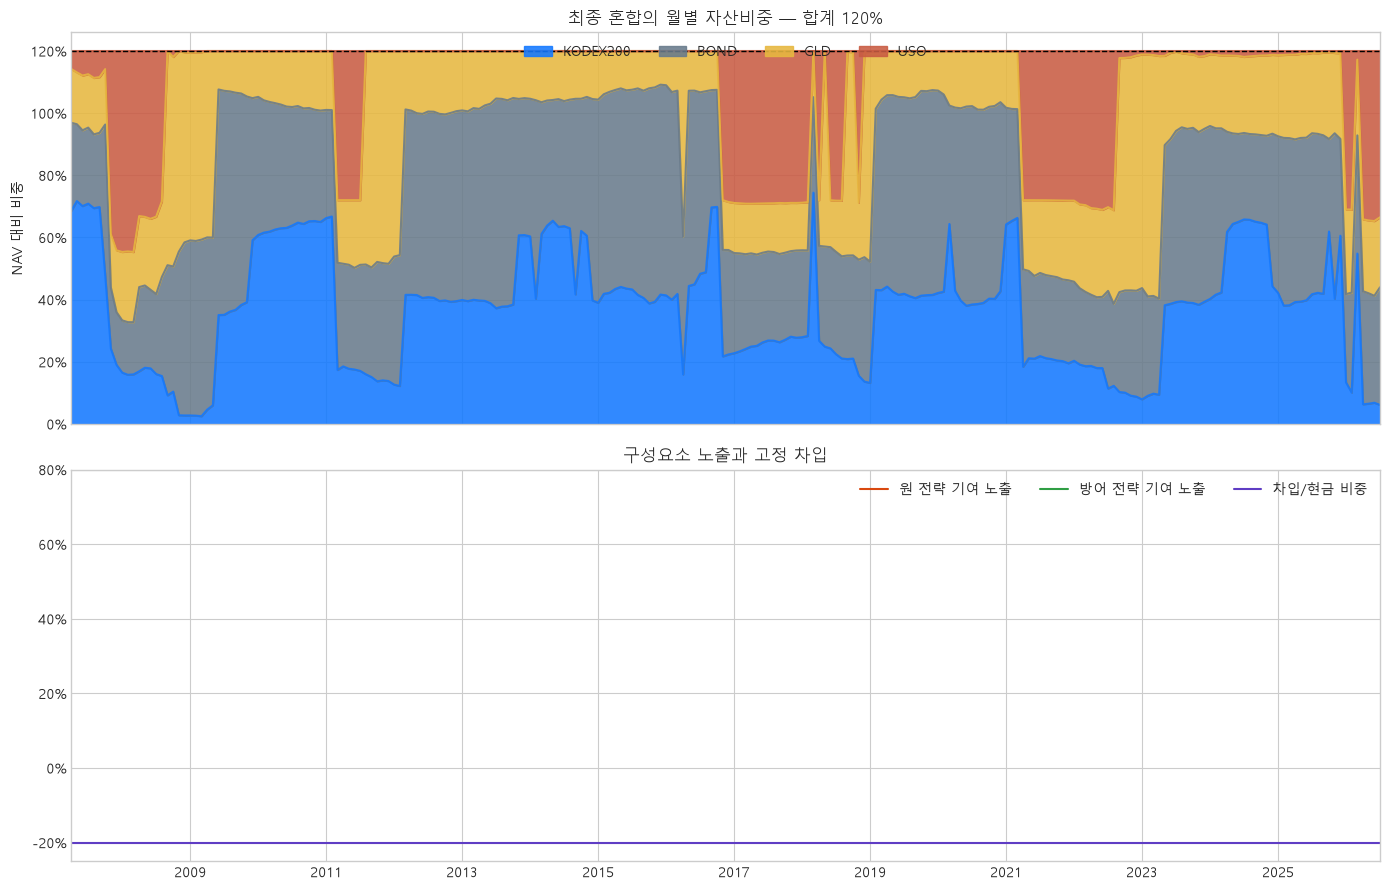

,평균 비중
KODEX200,36.6%
BOND,44.7%
GLD,25.3%
USO,13.4%
차입(현금),-20.0%


In [7]:
weight_cols = [f"w_{asset}" for asset in ASSETS]
weights = final[weight_cols].copy()
weights.columns = ASSETS
weights.index = weights.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
weights.plot.area(ax=axes[0], color=["#1479ff", "#697b8c", "#e7b840", "#c95c43"], alpha=0.88)
axes[0].axhline(1.20, color="black", ls="--", lw=1)
axes[0].set_ylim(0, 1.26)
axes[0].set_title("최종 혼합의 월별 자산비중 — 합계 120%")
axes[0].set_ylabel("NAV 대비 비중")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend(ncol=4, loc="upper center")

hard_share = final[[f"hard_w_{asset}" for asset in ASSETS]].mul(0.4 * 1.2).sum(axis=1)
def_share = final[[f"defensive_w_{asset}" for asset in ASSETS]].mul(0.6 * 1.2).sum(axis=1)
axes[1].plot(idx, hard_share, label="원 전략 기여 노출", color="#d9480f")
axes[1].plot(idx, def_share, label="방어 전략 기여 노출", color="#2f9e44")
axes[1].axhline(-0.20, label="차입/현금 비중", color="#5f3dc4")
axes[1].set_ylim(-0.25, 0.8)
axes[1].set_title("구성요소 노출과 고정 차입")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(ncol=3)
plt.tight_layout()
plt.show()

average_weights = weights.mean().to_frame("평균 비중")
average_weights.loc["차입(현금)"] = -0.20
display(average_weights.style.format("{:.1%}"))

## 7. 5년 이동성과와 주요 낙폭

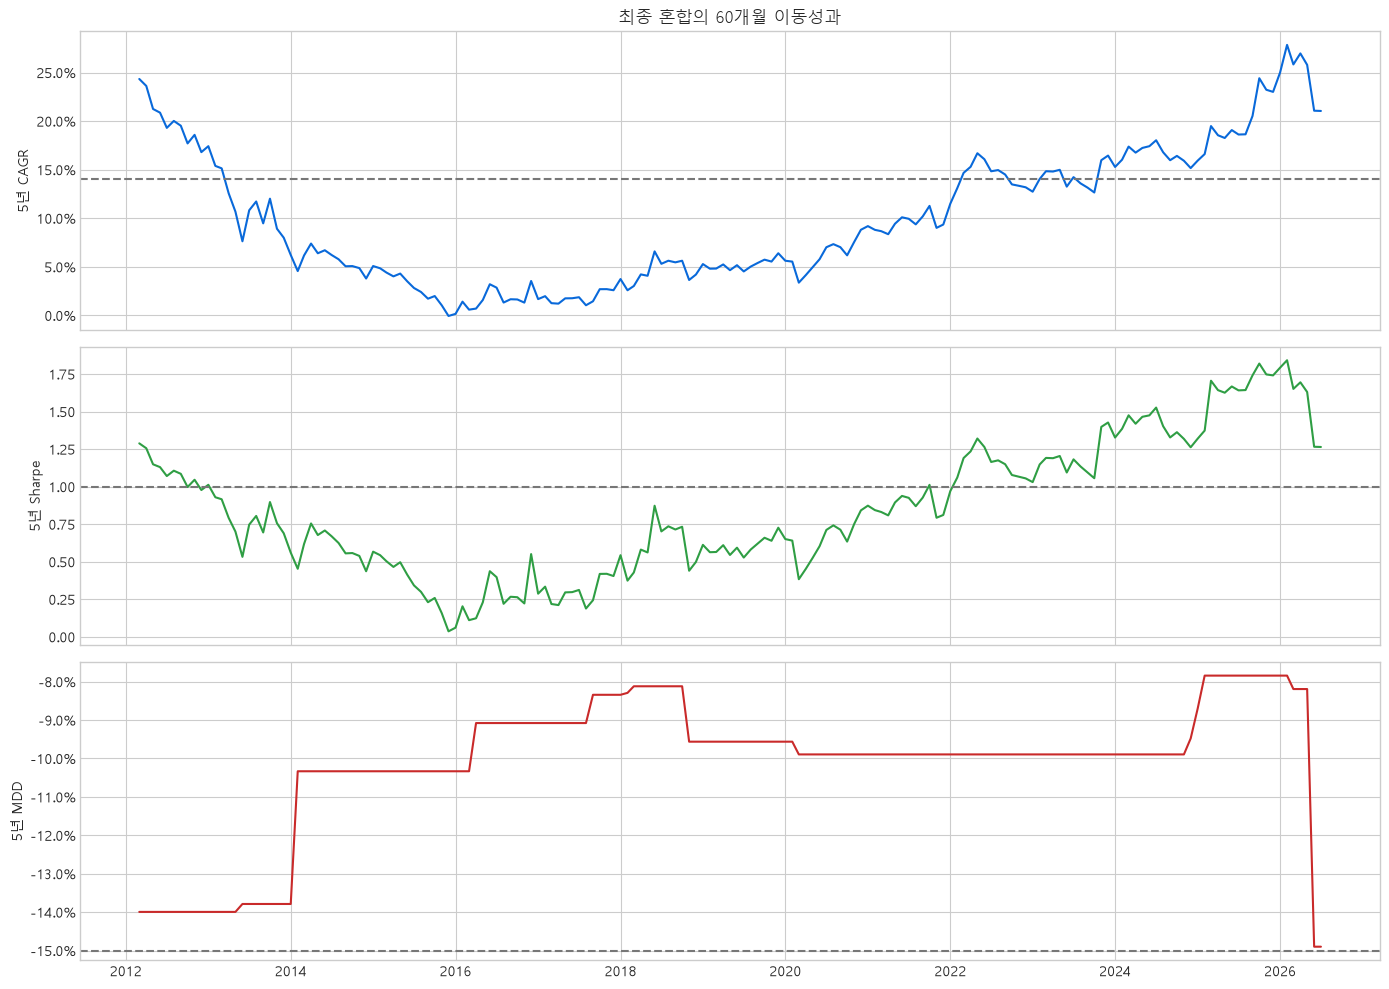

,Peak,Trough,Recovery,MDD,MonthsToRecovery
0,2026-02,2026-06,Unrecovered,-14.90%,5
1,2008-06,2008-10,2008-12,-13.99%,6
2,2009-02,2009-04,2009-12,-13.79%,10
3,2011-04,2011-06,2011-11,-10.33%,7
4,2019-12,2020-03,2020-07,-9.89%,7
5,2018-10,2018-11,2019-12,-9.56%,14
6,2012-09,2013-06,2016-04,-9.08%,43
7,2016-12,2017-08,2017-12,-8.12%,12
8,2022-05,2022-08,2023-03,-7.84%,10
9,2021-10,2021-11,2022-01,-7.38%,3


In [8]:
rolling = pd.read_csv(RESULTS / "final_blend_rolling60.csv")
rolling["EndMonth"] = pd.PeriodIndex(rolling["EndMonth"], freq="M").to_timestamp()
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(rolling["EndMonth"], rolling["CAGR"], color="#0969da")
axes[0].axhline(0.14, color="#777", ls="--")
axes[0].set_ylabel("5년 CAGR")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].plot(rolling["EndMonth"], rolling["Sharpe"], color="#2f9e44")
axes[1].axhline(1.0, color="#777", ls="--")
axes[1].set_ylabel("5년 Sharpe")
axes[2].plot(rolling["EndMonth"], rolling["MDD"], color="#c92a2a")
axes[2].axhline(-0.15, color="#777", ls="--")
axes[2].set_ylabel("5년 MDD")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("최종 혼합의 60개월 이동성과")
plt.tight_layout()
plt.show()

drawdowns = pd.read_csv(RESULTS / "final_blend_drawdown_episodes.csv")
display(drawdowns.head(10).style.format({"MDD": "{:.2%}", "MonthsToRecovery": "{:,.0f}"}))

## 8. 비용·금리·매개변수 민감도

### 거래·환전비용 민감도

,CostMultiplier,CAGR,Sharpe,MDD,Calmar
0,1×,14.30%,1.024,-14.90%,0.960
1,2×,13.93%,1.001,-15.23%,0.915
2,3×,13.56%,0.978,-15.56%,0.871


### 차입금리 민감도

,FinancingRate,CAGR,Sharpe,MDD,Calmar
0,4%,14.30%,1.024,-14.90%,0.960
1,6%,13.87%,0.997,-15.01%,0.924
2,8%,13.44%,0.970,-15.13%,0.889
3,10%,13.03%,0.944,-15.23%,0.855


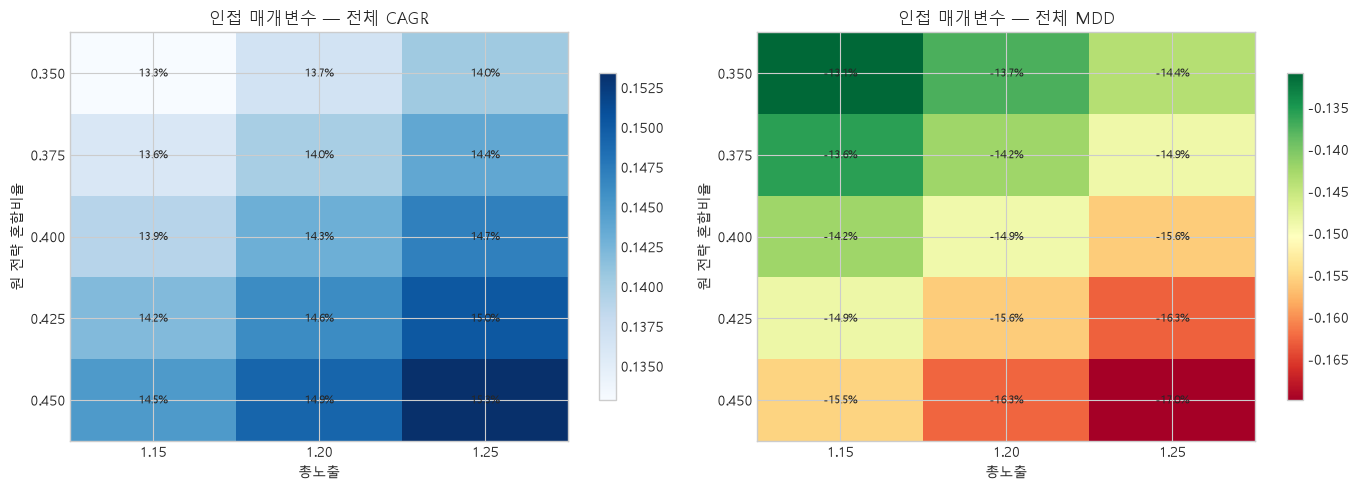

In [9]:
costs = pd.read_csv(RESULTS / "final_blend_cost_sensitivity.csv")
financing = pd.read_csv(RESULTS / "final_blend_financing_sensitivity.csv")
display(Markdown("### 거래·환전비용 민감도"))
display(costs[["CostMultiplier", "CAGR", "Sharpe", "MDD", "Calmar"]].style.format({
    "CostMultiplier": "{:.0f}×", "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "Calmar": "{:.3f}",
}))
display(Markdown("### 차입금리 민감도"))
display(financing[["FinancingRate", "CAGR", "Sharpe", "MDD", "Calmar"]].style.format({
    "FinancingRate": "{:.0%}", "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "Calmar": "{:.3f}",
}))

neighborhood = pd.read_csv(RESULTS / "final_blend_parameter_neighborhood.csv")
full_surface = neighborhood[neighborhood["Period"] == "full"]
cagr_surface = full_surface.pivot(index="HardFraction", columns="Leverage", values="CAGR")
mdd_surface = full_surface.pivot(index="HardFraction", columns="Leverage", values="MDD")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, cmap in [
    (axes[0], cagr_surface, "인접 매개변수 — 전체 CAGR", "Blues"),
    (axes[1], mdd_surface, "인접 매개변수 — 전체 MDD", "RdYlGn"),
]:
    image = ax.imshow(data.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(data.columns)), [f"{x:.2f}" for x in data.columns])
    ax.set_yticks(range(len(data.index)), [f"{x:.3f}" for x in data.index])
    ax.set_xlabel("총노출")
    ax.set_ylabel("원 전략 혼합비율")
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data.iloc[i,j]:.1%}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 9. 하위기간과 위기 에피소드

In [10]:
subperiods = pd.read_csv(RESULTS / "final_blend_subperiods.csv")
stress = pd.read_csv(RESULTS / "final_blend_stress_episodes.csv")
display(Markdown("### 하위기간"))
display(subperiods[["Subperiod", "Strategy", "CAGR", "Sharpe", "MDD", "Calmar"]].style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "Calmar": "{:.3f}",
}))
display(Markdown("### 위기 에피소드"))
display(stress[["Episode", "Strategy", "CAGR", "Sharpe", "MDD", "FinalMultiple"]].style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.3f}", "MDD": "{:.2%}", "FinalMultiple": "{:.2f}x",
}))

### 하위기간

,Subperiod,Strategy,CAGR,Sharpe,MDD,Calmar
0,2007-2009,Hard,54.23%,1.483,-25.25%,2.148
1,2007-2009,CurrentDefensive,15.55%,1.523,-8.27%,1.881
2,2007-2009,FinalBlend,36.40%,1.546,-13.99%,2.601
3,2010-2013,Hard,5.19%,0.397,-17.96%,0.289
4,2010-2013,CurrentDefensive,4.53%,0.797,-8.93%,0.508
5,2010-2013,FinalBlend,5.14%,0.534,-10.33%,0.497
6,2014-2017,Hard,3.33%,0.319,-25.16%,0.132
7,2014-2017,CurrentDefensive,4.89%,1.188,-3.03%,1.612
8,2014-2017,FinalBlend,4.53%,0.683,-8.12%,0.558
9,2018-2020,Hard,10.87%,0.591,-26.67%,0.408


### 위기 에피소드

,Episode,Strategy,CAGR,Sharpe,MDD,FinalMultiple
0,GlobalFinancialCrisis,Hard,50.13%,1.165,-25.25%,1.84x
1,GlobalFinancialCrisis,CurrentDefensive,10.47%,0.953,-8.27%,1.16x
2,GlobalFinancialCrisis,FinalBlend,30.85%,1.117,-13.99%,1.50x
3,EuroCommodityShock,Hard,-8.73%,-0.299,-9.27%,0.90x
4,EuroCommodityShock,CurrentDefensive,2.03%,0.348,-2.84%,1.02x
5,EuroCommodityShock,FinalBlend,-3.34%,-0.173,-5.90%,0.96x
6,OilDowncycle,Hard,-0.19%,0.005,-7.72%,1.00x
7,OilDowncycle,CurrentDefensive,4.27%,0.963,-1.97%,1.07x
8,OilDowncycle,FinalBlend,2.19%,0.412,-4.54%,1.04x
9,2018Selloff,Hard,-41.71%,-0.833,-20.68%,0.87x


## 10. 블록 부트스트랩 — MDD 15%는 보장이 아니다

In [11]:
bootstrap = pd.read_csv(RESULTS / "final_blend_bootstrap.csv")
with (RESULTS / "final_blend_validation.json").open(encoding="utf-8") as handle:
    validation = json.load(handle)

display(bootstrap.style.format({"P05": "{:.2%}", "Median": "{:.2%}", "P95": "{:.2%}"}))
prob = pd.Series(validation["bootstrap_probabilities"], name="확률/비율")
display(prob.to_frame().style.format("{:.1%}"))
display(Markdown(
    "같은 월수익 블록을 세 전략에 동시에 적용한 3,000회 쌍체 재표본 결과다. "
    "최종 혼합이 원 전략보다 MDD가 작을 확률은 거의 100%였지만, 절대 MDD 15% 이내 확률은 블록 6개월 약 31%, 12개월 약 54%였다. "
    "따라서 -14.90%는 점추정치이지 손실 한도가 아니다."
))

,BlockLength,Strategy,Metric,P05,Median,P95
0,6,CurrentDefensive,CAGR,5.43%,8.34%,11.73%
1,6,CurrentDefensive,Sharpe,82.78%,119.90%,156.98%
2,6,CurrentDefensive,MDD,-14.21%,-9.11%,-6.12%
3,6,FinalBlend,CAGR,9.16%,14.47%,20.73%
4,6,FinalBlend,Sharpe,73.47%,106.12%,139.60%
5,6,FinalBlend,MDD,-23.92%,-16.65%,-13.74%
6,6,Hard,CAGR,9.80%,18.53%,28.51%
7,6,Hard,Sharpe,54.95%,88.77%,122.66%
8,6,Hard,MDD,-44.84%,-30.85%,-22.58%
9,12,CurrentDefensive,CAGR,4.52%,7.53%,11.34%


,확률/비율
block6_mdd_better_than_hard,100.0%
block6_sharpe_better_than_hard,98.5%
block6_mdd_within_15,31.0%
block6_cagr_at_least_14,55.8%
block6_median_cagr_retention,78.1%
block12_mdd_better_than_hard,100.0%
block12_sharpe_better_than_hard,97.2%
block12_mdd_within_15,53.9%
block12_cagr_at_least_14,43.7%
block12_median_cagr_retention,77.2%


같은 월수익 블록을 세 전략에 동시에 적용한 3,000회 쌍체 재표본 결과다. 최종 혼합이 원 전략보다 MDD가 작을 확률은 거의 100%였지만, 절대 MDD 15% 이내 확률은 블록 6개월 약 31%, 12개월 약 54%였다. 따라서 -14.90%는 점추정치이지 손실 한도가 아니다.

## 11. 경기국면 판정력

In [12]:
regime_metrics = validation["regime_metrics"]
regime_table = pd.Series({
    "성장상태 균형정확도": regime_metrics["growth_balanced_accuracy"],
    "물가상태 균형정확도": regime_metrics["inflation_balanced_accuracy"],
    "4개 국면 정확도": regime_metrics["quadrant_accuracy"],
    "평가 월수": regime_metrics["n_months"],
}, name="결과").to_frame()
display(regime_table.style.format({"결과": lambda x: f"{x:.1%}" if x <= 1 else f"{x:.0f}"}))

growth_cm = pd.DataFrame(regime_metrics["growth_confusion"], index=["실제 Low", "실제 High"], columns=["예측 Low", "예측 High"])
inflation_cm = pd.DataFrame(regime_metrics["inflation_confusion"], index=["실제 Low", "실제 High"], columns=["예측 Low", "예측 High"])
display(Markdown("### 성장 혼동행렬")); display(growth_cm)
display(Markdown("### 물가 혼동행렬")); display(inflation_cm)
display(Markdown("최종 혼합은 국면분류기를 다시 학습하지 않는다. 따라서 수익률 개선을 위해 경기국면 정확도를 희생하거나 사후 조정하지 않았다."))

,결과
성장상태 균형정확도,86.3%
물가상태 균형정확도,88.9%
4개 국면 정확도,77.2%
평가 월수,232


### 성장 혼동행렬

,예측 Low,예측 High
실제 Low,110,19
실제 High,13,90


### 물가 혼동행렬

,예측 Low,예측 High
실제 Low,129,10
실제 High,14,79


최종 혼합은 국면분류기를 다시 학습하지 않는다. 따라서 수익률 개선을 위해 경기국면 정확도를 희생하거나 사후 조정하지 않았다.

## 12. 자동 검증

In [13]:
full_m = performance_summary(final["return"])
locked_m = performance_summary(final.loc["2018-01":, "return"])

assert signals.index.is_monotonic_increasing and signals.index.is_unique
assert (signals["signal_month"] < signals.index).all(), "신호월은 투자월보다 앞서야 함"
assert np.isfinite(final["return"]).all()
assert (final[weight_cols].sum(axis=1).sub(1.20).abs() < 1e-8).all()
assert (final[weight_cols] >= -1e-12).all().all()
assert (final[["trade_cost", "fx_cost"]] >= 0).all().all()
assert full_m["MDD"] >= -0.15 and locked_m["MDD"] >= -0.15
assert full_m["Sharpe"] >= 1.0 and locked_m["Sharpe"] >= 1.0
assert full_m["CAGR"] / full_hard["CAGR"] >= 0.75
assert set(ASSETS) == {"KODEX200", "BOND", "GLD", "USO"}
print("시점·자산범위·비중·비용·잠금구간·MDD·Sharpe 검증을 통과했습니다.")

시점·자산범위·비중·비용·잠금구간·MDD·Sharpe 검증을 통과했습니다.


## 13. 결론과 운영상 주의

### 채택안

- 원 고수익 국면비중 40%, 기존 방어비중 60%, 총노출 120%.
- 전체 CAGR **14.30%**, Sharpe **1.024**, MDD **-14.90%**.
- 잠금구간 CAGR **17.07%**, Sharpe **1.164**, MDD **-14.90%**.
- 원 전략 CAGR의 약 **77.5%**를 유지하면서 역사적 MDD를 약 11.8%p 줄였다.
- 신규 헤지 자산은 없다. 경기국면 정확도는 성장 86.3%, 물가 88.9%, 4국면 77.2%로 기존 판정을 유지한다.

### 반드시 함께 읽어야 하는 한계

1. MDD 여유가 0.10%p뿐이다. 비용 2배에서는 MDD가 약 -15.23%로 상한을 넘는다.
2. 2026년 2월 고점 이후 6월 저점의 -14.90% 낙폭은 데이터 종료 시점까지 회복되지 않았다.
3. 블록 부트스트랩상 MDD 15% 이내 확률은 31~54%이므로 실제 위험한도는 더 넓게 잡아야 한다.
4. 20% 차입은 마진콜·금리변동·추적오차를 만든다. 실제 금융비용이 8%면 전체 CAGR은 약 13.44%, MDD는 약 -15.13%다.
5. GDP·물가 실시간 빈티지, 세금, 시장충격, 실제 체결 슬리피지는 완전 반영되지 않았다. 2009-03 이전 KODEX200은 KOSPI200 프록시다.

따라서 이 안은 ‘MDD 15% 보장’ 전략이 아니라, **추가 헤지 자산 없이 원 전략의 수익성을 최대한 보존한 역사적 절충안**이다. 실전에서는 총노출 1.15~1.20 범위를 위험예산에 따라 선택하고, 비용과 차입금리를 별도로 관리해야 한다.